  1. ORBITS PARAMETERS
LEO Radius (r1): 6678.14 km | Velocity: 7.7258 km/s
Target Radius (r2): 42164.14 km | Velocity: 3.0747 km/s
Remote Radius (r_b): 267125.48 km
Radius Ratio (r2/r1): 6.31
Note: Since r2/r1 < 11.94, the Bi-Elliptic transfer is LESS efficient than Hohmann.

  2. BI-ELLIPTIC TRANSFER RESULTS
Time of Flight Ellipse 1: 2.92 days
Time of Flight Ellipse 2: 3.50 days
Total Time of Flight:     6.42 days

  3. TOTAL DELTA-V BUDGET
Delta V 1 (LEO Departure):     3.0660 km/s
Delta V 2 (Remote Apogee r_b): 0.3680 km/s
Delta V 3 (Braking at r2):     0.9663 km/s
TOTAL DELTA V:                 4.4004 km/s


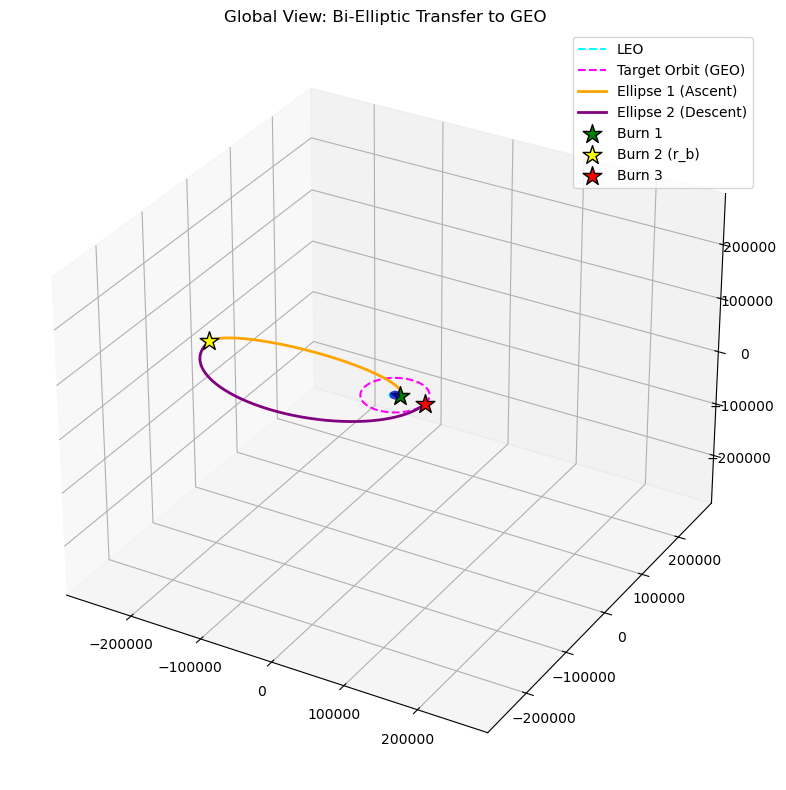

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import orekit
from orekit.pyhelpers import setup_orekit_curdir
from org.orekit.utils import Constants

# ==========================================
# 1. OREKIT ENVIRONMENT INITIALIZATION
# ==========================================
orekit.initVM()
setup_orekit_curdir('C:/Users/Simone/Downloads/orekit-data-main')

# ==========================================
# 2. PHYSICAL CONSTANTS (From Orekit, in km)
# ==========================================
mu_E = Constants.WGS84_EARTH_MU / 1e9                   # Earth's gravitational parameter [km^3/s^2]
R_E = Constants.WGS84_EARTH_EQUATORIAL_RADIUS / 1000.0  # Earth's mean equatorial radius [km]

# ==========================================
# 3. PARKING AND MANEUVER ORBITS DATA
# ==========================================
# Initial Orbit (LEO)
h1 = 300.0                     # LEO altitude [km]
r1 = R_E + h1                  # LEO radius [km]
v1 = np.sqrt(mu_E / r1)        # LEO circular velocity [km/s]

# Final Orbit (PURE GEO)
h2 = 35786.0                   # GEO altitude [km]
r2 = R_E + h2                  # GEO radius [km]
v2 = np.sqrt(mu_E / r2)        # GEO circular velocity [km/s]

# Intermediate maneuver radius (Remote apogee, r_b)
r_b = 40.0 * r1                # Remote apogee selected to investigate a high-radius bi-elliptic transfer

# --- Radius Ratio Check (Hohmann vs Bi-Elliptic) ---
ratio = r2 / r1
is_convenient = ratio > 11.94

print("========================================================")
print("  1. ORBITS PARAMETERS")
print("========================================================")
print(f"LEO Radius (r1): {r1:.2f} km | Velocity: {v1:.4f} km/s")
print(f"Target Radius (r2): {r2:.2f} km | Velocity: {v2:.4f} km/s")
print(f"Remote Radius (r_b): {r_b:.2f} km")
print(f"Radius Ratio (r2/r1): {ratio:.2f}")

if is_convenient:
    print("Note: Since r2/r1 > 11.94, the Bi-Elliptic transfer is MORE efficient (lower Delta-V) than Hohmann.")
else:
    print("Note: Since r2/r1 < 11.94, the Bi-Elliptic transfer is LESS efficient than Hohmann.")
print("")

# ==========================================
# 4. BI-ELLIPTIC TRANSFER CALCULATION (3 Impulses)
# ==========================================
# --- Ellipse 1: From r1 (perigee) to r_b (apogee) ---
a_tx1 = (r1 + r_b) / 2.0
v_tx1_perigeo = np.sqrt(mu_E * (2/r1 - 1/a_tx1))
v_tx1_apogeo = np.sqrt(mu_E * (2/r_b - 1/a_tx1))

# --- Ellipse 2: From r_b (apogee) to r2 (perigee) ---
a_tx2 = (r_b + r2) / 2.0
v_tx2_apogeo = np.sqrt(mu_E * (2/r_b - 1/a_tx2))
v_tx2_perigeo = np.sqrt(mu_E * (2/r2 - 1/a_tx2))

# --- Delta-V Calculation ---
DeltaV_1 = v_tx1_perigeo - v1               # Acceleration at perigee (Burn 1)
DeltaV_2 = v_tx2_apogeo - v_tx1_apogeo      # Acceleration at remote apogee (Burn 2)
DeltaV_3 = v_tx2_perigeo - v2               # Braking at new target perigee (Burn 3)

DeltaV_Tot_BiElliptic = DeltaV_1 + DeltaV_2 + DeltaV_3

# Time of Flight (Half period for each ellipse)
TOF1_sec = np.pi * np.sqrt((a_tx1**3) / mu_E)
TOF2_sec = np.pi * np.sqrt((a_tx2**3) / mu_E)
TOF_Tot_days = (TOF1_sec + TOF2_sec) / 86400.0

print("========================================================")
print("  2. BI-ELLIPTIC TRANSFER RESULTS")
print("========================================================")
print(f"Time of Flight Ellipse 1: {TOF1_sec/86400.0:.2f} days")
print(f"Time of Flight Ellipse 2: {TOF2_sec/86400.0:.2f} days")
print(f"Total Time of Flight:     {TOF_Tot_days:.2f} days\n")

print("========================================================")
print("  3. TOTAL DELTA-V BUDGET")
print("========================================================")
print(f"Delta V 1 (LEO Departure):     {DeltaV_1:.4f} km/s")
print(f"Delta V 2 (Remote Apogee r_b): {DeltaV_2:.4f} km/s")
print(f"Delta V 3 (Braking at r2):     {DeltaV_3:.4f} km/s")
print(f"TOTAL DELTA V:                 {DeltaV_Tot_BiElliptic:.4f} km/s")
print("========================================================")

# ==========================================
# 5. 3D VISUALIZATION (GLOBAL VIEW)
# ==========================================
fig = plt.figure(figsize=(18, 8))

# Angular arrays
u, v = np.mgrid[0:2*np.pi:40j, 0:np.pi:20j]
theta_orb = np.linspace(0, 2*np.pi, 200)

# Circular Orbits
x_leo = r1 * np.cos(theta_orb); y_leo = r1 * np.sin(theta_orb)
x_target = r2 * np.cos(theta_orb); y_target = r2 * np.sin(theta_orb)

# Ellipse 1 (Half orbit: from 0 to pi)
theta_tx1 = np.linspace(0, np.pi, 200)
ecc1 = (r_b - r1) / (r_b + r1)
r_plot1 = (a_tx1 * (1 - ecc1**2)) / (1 + ecc1 * np.cos(theta_tx1))
x_tx1 = r_plot1 * np.cos(theta_tx1)
y_tx1 = r_plot1 * np.sin(theta_tx1)

# Ellipse 2 (Half orbit: from pi to 2*pi, returning down)
theta_tx2 = np.linspace(np.pi, 2*np.pi, 200)
ecc2 = (r_b - r2) / (r_b + r2)
r_plot2_geom = (a_tx2 * (1 - ecc2**2)) / (1 + ecc2 * np.cos(theta_tx2)) 
x_tx2 = r_plot2_geom * np.cos(theta_tx2)
y_tx2 = r_plot2_geom * np.sin(theta_tx2)

z_zeros = np.zeros(200)

# ---------------------------------------------------------
# SUBPLOT 1: GLOBAL VIEW (Scaled on r_b)
# ---------------------------------------------------------
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(R_E * np.cos(u) * np.sin(v), R_E * np.sin(u) * np.sin(v), R_E * np.cos(v), color='blue', alpha=0.6)

ax1.plot(x_leo, y_leo, z_zeros, color='cyan', linestyle='--', label='LEO')
ax1.plot(x_target, y_target, z_zeros, color='magenta', linestyle='--', label='Target Orbit (GEO)')

ax1.plot(x_tx1, y_tx1, z_zeros, label='Ellipse 1 (Ascent)', color='orange', linewidth=2)
ax1.plot(x_tx2, y_tx2, z_zeros, label='Ellipse 2 (Descent)', color='purple', linewidth=2)

ax1.scatter([x_tx1[0]], [y_tx1[0]], [0], color='green', s=200, marker='*', edgecolor='black', label='Burn 1')
ax1.scatter([x_tx1[-1]], [y_tx1[-1]], [0], color='yellow', s=200, marker='*', edgecolor='black', label='Burn 2 (r_b)')
ax1.scatter([x_tx2[-1]], [y_tx2[-1]], [0], color='red', s=200, marker='*', edgecolor='black', label='Burn 3')

ax1.set_xlim([-r_b*1.1, r_b*1.1]); ax1.set_ylim([-r_b*1.1, r_b*1.1]); ax1.set_zlim([-r_b*1.1, r_b*1.1])
ax1.set_title('Global View: Bi-Elliptic Transfer to GEO')
ax1.legend()

fig.tight_layout()
fig.savefig('bielliptic_transfer_plot.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()